In [2]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import pandas as pd


housing = fetch_california_housing(as_frame=True)
X = housing.data
y  = housing.target


In [3]:

print(X.head())
print(X.shape)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
(20640, 8)


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np


X_train, X_test, y_train,y_test = train_test_split(X,y, test_size=0.3, random_state=42) 
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R^2 Score: {r2:.4f}")




Mean Squared Error: 0.530567782476675
Root Mean Squared Error: 0.73
R^2 Score: 0.5958


In [7]:
#Feature importane / coefficients

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
}).sort_values(by='Coefficient', ascending=False)

print('Linear Regression Coefficients:')
print(coef_df)

Linear Regression Coefficients:
      Feature   Coefficient
3   AveBedrms  7.785996e-01
0      MedInc  4.458226e-01
1    HouseAge  9.681868e-03
4  Population -7.757404e-07
5    AveOccup -3.370027e-03
2    AveRooms -1.220951e-01
6    Latitude -4.185367e-01
7   Longitude -4.336880e-01


In [ ]:
from sklearn.ensemble import RandomForestRegressor

#training

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

#predition

y_pred_rf = rf.predict(X_test)

#evaluation

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results:")
print(f'rmse: {rmse_rf:.2f}')
print(f'r2: {r2_rf:.4f}')

Random Forest Results:
rmse: 0.51
r2: 0.8047


In [10]:
import matplotlib.pyplot as plt

#get geature importance

importances = rf.feature_importances_
feat_df = pd.DataFrame({
    'Feature':X.columns,
    'Importance':importances

}).sort_values(by='Importance', ascending=False)

print("Random Forest Feature Importance:")
print(feat_df)

Random Forest Feature Importance:
      Feature  Importance
0      MedInc    0.525996
5    AveOccup    0.138238
7   Longitude    0.086133
6    Latitude    0.086099
1    HouseAge    0.054663
2    AveRooms    0.047174
4  Population    0.031724
3   AveBedrms    0.029973


<function matplotlib.pyplot.show(close=None, block=None)>

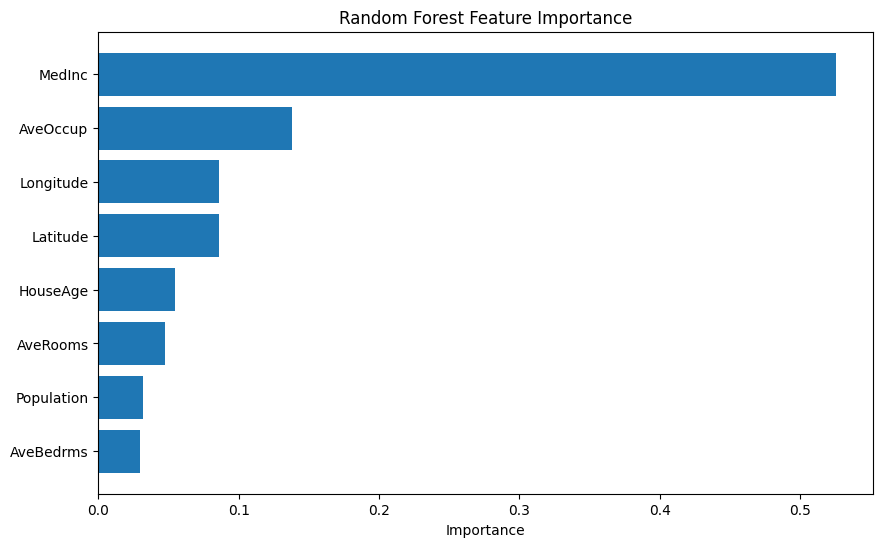

In [16]:
#plot

plt.figure(figsize=(10,6))
plt.barh(feat_df['Feature'], feat_df['Importance'])
plt.gca().invert_yaxis() #puts biggest value ontop
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show

rf outperforms lr, median income drives house prices.

1. load dataset, prepare x,y
2. split train test
3. train lr
 -print rmse and r^2
 -show coefficient
4. train rf 
 -print rmse and r^2
 -show feature importance chart
